Using device: cuda
Train size: 8549, Test size: 3665, Dim: 576
Number of handcrafted unpenalized features k = 11
Running experiment with handcrafted unpenalized features...

Repetition 1/10
k=0  | lambda=1e-02 | Test MSE=0.4338
k=11 | lambda=1e-02 | Test MSE=0.3760
k=0  | lambda=1e-03 | Test MSE=0.2292
k=11 | lambda=1e-03 | Test MSE=0.2300
k=0  | lambda=1e-04 | Test MSE=0.2146
k=11 | lambda=1e-04 | Test MSE=0.1516
k=0  | lambda=1e-05 | Test MSE=0.7589
k=11 | lambda=1e-05 | Test MSE=0.1082
k=0  | lambda=1e-06 | Test MSE=0.6168
k=11 | lambda=1e-06 | Test MSE=1.7767

Repetition 2/10
k=0  | lambda=1e-02 | Test MSE=0.4236
k=11 | lambda=1e-02 | Test MSE=0.3808
k=0  | lambda=1e-03 | Test MSE=0.2658
k=11 | lambda=1e-03 | Test MSE=0.2217
k=0  | lambda=1e-04 | Test MSE=0.3291
k=11 | lambda=1e-04 | Test MSE=0.2980
k=0  | lambda=1e-05 | Test MSE=0.5359
k=11 | lambda=1e-05 | Test MSE=0.8476
k=0  | lambda=1e-06 | Test MSE=0.2628
k=11 | lambda=1e-06 | Test MSE=2.5230

Repetition 3/10
k=0  | lambda=1e

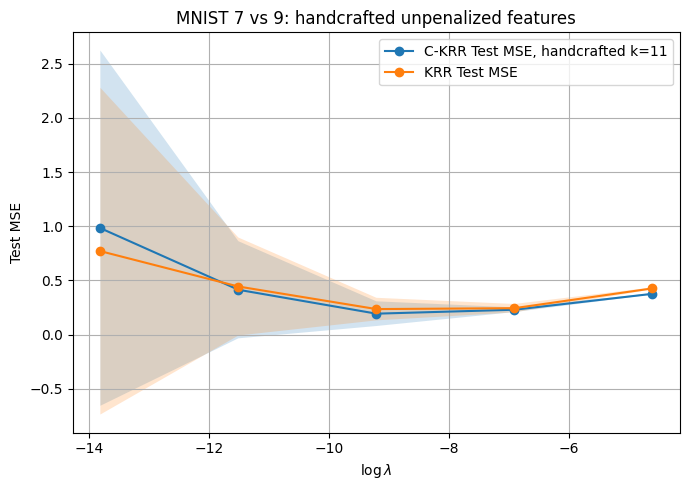


Summary:
lambda=1e-02 | KRR=0.4268 | C-KRR handcrafted=0.3767
lambda=1e-03 | KRR=0.2443 | C-KRR handcrafted=0.2299
lambda=1e-04 | KRR=0.2359 | C-KRR handcrafted=0.1936
lambda=1e-05 | KRR=0.4441 | C-KRR handcrafted=0.4141
lambda=1e-06 | KRR=0.7704 | C-KRR handcrafted=0.9827


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# ============================================================
# 0. Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 1. Load MNIST 7 vs 9 (keep BOTH flat vectors and raw 24x24 images)
# ============================================================
transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

X_flat_list = []
X_img_list = []
y_list = []

for img, label in mnist_train:
    if label in [7, 9]:
        arr = img.numpy().squeeze()          # (28,28)
        arr = arr[2:-2, 2:-2]                # crop to (24,24)
        arr = arr.astype(np.float32)

        X_img_list.append(arr)               # keep image form for handcrafted features
        X_flat_list.append(arr.flatten())    # keep flat form for random features
        y_list.append(+1 if label == 7 else -1)

X_flat = np.array(X_flat_list, dtype=np.float32)   # (N, 576)
X_img  = np.array(X_img_list,  dtype=np.float32)   # (N, 24, 24)
y      = np.array(y_list,      dtype=np.float32)   # (N,)

# train / test split
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.3, random_state=42, stratify=y
)

X_train_full = X_flat[idx_train]
X_test_full  = X_flat[idx_test]
X_train_img  = X_img[idx_train]
X_test_img   = X_img[idx_test]
y_train      = y[idx_train]
y_test       = y[idx_test]

# Standardize raw pixel vectors for random-feature part
pixel_scaler = StandardScaler()
pixel_scaler.fit(X_train_full)
X_train = pixel_scaler.transform(X_train_full).astype(np.float32)
X_test  = pixel_scaler.transform(X_test_full ).astype(np.float32)

N_train, d = X_train.shape
N_test = X_test.shape[0]
print(f"Train size: {N_train}, Test size: {N_test}, Dim: {d}")

# ============================================================
# 2. Handcrafted unpenalized features from raw 24x24 images
# ============================================================
def handcrafted_features(images):
    """
    images: numpy array of shape (N, 24, 24), nonnegative grayscale values
    returns: numpy array of shape (N, 11)
    features:
      0: total ink
      1: center of mass x
      2: center of mass y
      3: second central moment xx
      4: second central moment yy
      5: second central moment xy
      6: upper-half ink
      7: lower-half ink
      8: left-half ink
      9: right-half ink
     10: central 8x8 ink
    """
    images = np.asarray(images, dtype=np.float32)
    N, H, W = images.shape
    eps = 1e-8

    yy, xx = np.meshgrid(
        np.arange(H, dtype=np.float32),
        np.arange(W, dtype=np.float32),
        indexing="ij"
    )

    feats = np.zeros((N, 11), dtype=np.float32)

    for i in range(N):
        img = images[i]
        total = img.sum()

        feats[i, 0] = total

        if total > eps:
            cx = (img * xx).sum() / total
            cy = (img * yy).sum() / total
        else:
            cx = (W - 1) / 2.0
            cy = (H - 1) / 2.0

        feats[i, 1] = cx
        feats[i, 2] = cy

        # second central moments
        dx = xx - cx
        dy = yy - cy
        mxx = (img * (dx ** 2)).sum() / max(total, eps)
        myy = (img * (dy ** 2)).sum() / max(total, eps)
        mxy = (img * (dx * dy)).sum() / max(total, eps)

        feats[i, 3] = mxx
        feats[i, 4] = myy
        feats[i, 5] = mxy

        # half-plane ink
        upper = img[:H // 2, :].sum()
        lower = img[H // 2:, :].sum()
        left  = img[:, :W // 2].sum()
        right = img[:, W // 2:].sum()

        feats[i, 6] = upper
        feats[i, 7] = lower
        feats[i, 8] = left
        feats[i, 9] = right

        # central 8x8 block
        h0 = (H - 8) // 2
        w0 = (W - 8) // 2
        central = img[h0:h0+8, w0:w0+8].sum()
        feats[i, 10] = central

    return feats

Phi_train_np = handcrafted_features(X_train_img)
Phi_test_np  = handcrafted_features(X_test_img)

# standardize handcrafted features using train statistics only
feat_scaler = StandardScaler()
feat_scaler.fit(Phi_train_np)
Phi_train_np = feat_scaler.transform(Phi_train_np).astype(np.float32)
Phi_test_np  = feat_scaler.transform(Phi_test_np ).astype(np.float32)

k = Phi_train_np.shape[1]
print(f"Number of handcrafted unpenalized features k = {k}")

# ============================================================
# 3. Move data to GPU
# ============================================================
X_train_t = torch.from_numpy(X_train).to(device).float()
X_test_t  = torch.from_numpy(X_test ).to(device).float()

Phi_train_t = torch.from_numpy(Phi_train_np).to(device).float()
Phi_test_t  = torch.from_numpy(Phi_test_np ).to(device).float()

y_train_t = torch.from_numpy(y_train).to(device).float()
y_test_t  = torch.from_numpy(y_test ).to(device).float()

# ============================================================
# 4. Random ReLU features on GPU
# ============================================================
def build_random_features_gpu(X, omega, b):
    z = X @ omega.T + b.unsqueeze(0)
    return torch.relu(z)

# ============================================================
# 5. RFRR / C-KRR with handcrafted unpenalized features
# ============================================================
def run_rfrr_gpu(X_train, y_train, X_test, y_test,
                 Phi_train, Phi_test,
                 k, m=10000, sigma=1.0, lam=0.1):
    """
    X_train, X_test: standardized raw-pixel tensors
    Phi_train, Phi_test: handcrafted unpenalized feature tensors
    y_train, y_test: labels
    k: number of unpenalized handcrafted features
    m: number of penalized random ReLU features
    """
    N, d = X_train.shape
    N_test = X_test.shape[0]

    # random penalized features only
    omega = torch.randn(m, d, device=device) * (1.0 / sigma)
    b = 2.0 * torch.rand(m, device=device) - 1.0

    if k > 0:
        Phi_tr = Phi_train[:, :k]
        Phi_te = Phi_test[:, :k]
    else:
        Phi_tr = torch.zeros((N, 0), device=device)
        Phi_te = torch.zeros((N_test, 0), device=device)

    Psi_train = build_random_features_gpu(X_train, omega, b) / np.sqrt(m)
    Psi_test  = build_random_features_gpu(X_test,  omega, b) / np.sqrt(m)

    A_train = torch.cat([Phi_tr, Psi_train], dim=1)
    A_test  = torch.cat([Phi_te, Psi_test], dim=1)

    penalty = torch.cat([
        torch.zeros(k, device=device),
        lam * torch.ones(m, device=device)
    ])

    H = (A_train.T @ A_train) / N
    b_vec = (A_train.T @ y_train) / N

    M = H + torch.diag(penalty)
    M = M + 1e-10 * torch.eye(M.shape[0], device=device)

    w = torch.linalg.solve(M, b_vec)

    y_pred_train = A_train @ w
    y_pred_test  = A_test  @ w

    mse_train = torch.mean((y_pred_train - y_train) ** 2).item()
    mse_test  = torch.mean((y_pred_test  - y_test ) ** 2).item()

    return mse_train, mse_test

# ============================================================
# 6. Experiment settings
# ============================================================
m = 10000
sigma = np.sqrt(d)
R = 10

lambda_candidates = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

# standard KRR baseline here corresponds to k=0
mses_test_k0 = []
mses_test_kH = []

print("Running experiment with handcrafted unpenalized features...")
for r in range(R):
    print(f"\nRepetition {r+1}/{R}")
    rep_test0 = []
    rep_testH = []

    for lam in lambda_candidates:
        mse_train0, mse_test0 = run_rfrr_gpu(
            X_train_t, y_train_t,
            X_test_t, y_test_t,
            Phi_train_t, Phi_test_t,
            k=0, m=m, sigma=sigma, lam=lam
        )
        rep_test0.append(mse_test0)
        print(f"k=0  | lambda={lam:.0e} | Test MSE={mse_test0:.4f}")

        mse_trainH, mse_testH = run_rfrr_gpu(
            X_train_t, y_train_t,
            X_test_t, y_test_t,
            Phi_train_t, Phi_test_t,
            k=k, m=m, sigma=sigma, lam=lam
        )
        rep_testH.append(mse_testH)
        print(f"k={k:2d} | lambda={lam:.0e} | Test MSE={mse_testH:.4f}")

    mses_test_k0.append(rep_test0)
    mses_test_kH.append(rep_testH)

mses_test_k0 = np.array(mses_test_k0)
mses_test_kH = np.array(mses_test_kH)

test_means0 = mses_test_k0.mean(axis=0)
test_stds0  = mses_test_k0.std(axis=0)

test_meansH = mses_test_kH.mean(axis=0)
test_stdsH  = mses_test_kH.std(axis=0)

# ============================================================
# 7. Plot
# ============================================================
ci = 1.96

test_upper0 = test_means0 + ci * test_stds0
test_lower0 = test_means0 - ci * test_stds0

test_upperH = test_meansH + ci * test_stdsH
test_lowerH = test_meansH - ci * test_stdsH

plt.figure(figsize=(7, 5))

xvals = np.log(lambda_candidates)

plt.plot(xvals, test_meansH, marker="o",
         label=f"C-KRR Test MSE, handcrafted k={k}")
plt.fill_between(xvals, test_lowerH, test_upperH, alpha=0.2)

plt.plot(xvals, test_means0, marker="o",
         label="KRR Test MSE")
plt.fill_between(xvals, test_lower0, test_upper0, alpha=0.2)

plt.xlabel(r"$\log \lambda$")
plt.ylabel("Test MSE")
plt.title("MNIST 7 vs 9: handcrafted unpenalized features")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("mnist_handcrafted_features.png", dpi=600, bbox_inches="tight")
plt.show()

# ============================================================
# 8. Print summary
# ============================================================
print("\nSummary:")
for lam, m0, mH in zip(lambda_candidates, test_means0, test_meansH):
    print(f"lambda={lam:.0e} | KRR={m0:.4f} | C-KRR handcrafted={mH:.4f}")